# Garfunkle - RecSys Extraction Attack
<small><em>By Alexander Schoolcraft, Scott Fitz Gerald, Josh Murphy, and Simon Kuester</em></small>
## I. Load the GitHub files
Copied the GitHub repo to a personal one to use for this attack. Then, due to SEVERAL runtime crashes, where we lost every bit of data that was run already, cloned the repo into Google Drive, and ran it off of that to create persistance.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

*This cell only has to be run the first time - if the system crashes, the data will still be there. The other two of these initializers (mounting the drive and then navigating to the repo root) needs to be run each time.*

In [ ]:
with open('/content/drive/MyDrive/token.txt') as f:
    GITHUB_TOKEN = f.read().strip()
!git clone https://{GITHUB_TOKEN}@github.com/Huraharah/RecSys-Extraction-Attack '/content/drive/MyDrive/CSCI4880 Group Project/Group Project/RecSys'

In [ ]:
%cd '/content/drive/MyDrive/CSCI4880 Group Project/Group Project/RecSys/'

## II. Install the requirements
The 'requirements.txt' file was built to install into a conda environment, but this is the list from the README.md file.

In [ ]:
!pip install pandas wget libarchive-c faiss-cpu tqdm tensorboard
!pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124

** (With the large list of required libraries, the output from this has been removed.) **

# III. Conduct the Attack!

This attack was ran against all three models presented, BERT4Rec, SASRec, and NARM, using the "Games" dataset.

-_There was an issue with the sourcecode that was making it not read the arguments correctly and run for 1000 epochs. We modified the code to only run for 30 instead._

__For each run, it would prompt for 3 user inputs before running the attack: Dataset, Model, and GPU core to use. We used 'g' for 'Games' for the dataset, and '0' for the GPU (first available), and then 'b', 's', or 'n' for BERT4Rec, SASRec, and NARM, respectively.__

## A. Train the initial Black-Box Recommender Models


### 1. BERT4Rec model
The most complex of the three models. Transformer-based, with attention layers, creates a very complex network to train.

In [ ]:
!python train.py

2024-11-04 15:10:39.679119: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-04 15:10:39.696163: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-04 15:10:39.717453: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-04 15:10:39.723821: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-04 15:10:39.739226: I tensorflow/core/platform/cpu_feature_guar

### 2. SASRec Model
A decent middle-ground model. Still transformer based, but does not have attention layers, leading to lower complexity.

In [ ]:
!python train.py

2024-11-04 15:18:09.010995: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-04 15:18:09.027819: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-04 15:18:09.048492: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-04 15:18:09.054712: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-04 15:18:09.069518: I tensorflow/core/platform/cpu_feature_guar

### 3. NARM Model
Least complex of the three models. Combines RNN with attention mechanisms, leading to a much lower training time.

In [ ]:
!python train.py

2024-11-04 15:50:59.560768: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-04 15:50:59.578746: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-04 15:50:59.600289: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-04 15:50:59.606910: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-04 15:50:59.622517: I tensorflow/core/platform/cpu_feature_guar

## B. Extract the trained Black-Box Recommender Model

This was done against the three models, using a sequence budget of 15000, and extracting the model to the same model (BERT to BERT, SYSRec to SYSRec, and NARM to NARM)



### 1. BERT4Rec Model

In [ ]:
!python distill.py

2024-11-04 16:18:42.416601: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-04 16:18:42.435409: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-04 16:18:42.457140: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-04 16:18:42.463704: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-04 16:18:42.479616: I tensorflow/core/platform/cpu_feature_guar

### 2. SASRec Model

In [ ]:
!python distill.py

2024-11-04 19:16:41.676220: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-04 19:16:41.693674: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-04 19:16:41.714552: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-04 19:16:41.720909: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-04 19:16:41.736048: I tensorflow/core/platform/cpu_feature_guar

### 3. NARM Model

In [ ]:
!python distill.py

2024-11-04 21:04:39.777694: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-04 21:04:39.794869: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-04 21:04:39.816078: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-04 21:04:39.822507: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-04 21:04:39.837769: I tensorflow/core/platform/cpu_feature_guar

## C. Attack the trained Black-Box Recommender Models
This step used the same white-box model as extracted for each model in step (B), using the autoregressive model.

### 1. BERT4Rec Model

In [ ]:
!python attack.py

2024-11-05 00:24:04.232131: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-05 00:24:04.248793: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-05 00:24:04.269848: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-05 00:24:04.276133: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-05 00:24:04.291128: I tensorflow/core/platform/cpu_feature_guar

### 2. SASRec Model

In [ ]:
!python attack.py

2024-11-05 00:46:28.682103: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-05 00:46:28.699514: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-05 00:46:28.720977: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-05 00:46:28.727400: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-05 00:46:28.743149: I tensorflow/core/platform/cpu_feature_guar

### 3. NARM Model

In [ ]:
!python attack.py

2024-11-05 14:49:07.806524: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-05 14:49:07.823466: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-05 14:49:07.845010: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-05 14:49:07.851484: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-05 14:49:07.867002: I tensorflow/core/platform/cpu_feature_guar

## D. Poison the trained Black-Box Recommender Models
This step uses the data produced in step (C) to pollute the model, causing it to recommend the targeted items far more frequently.

### 1. BERT4Rec Model

In [ ]:
!python retrain.py

2024-11-05 18:54:17.799237: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-05 18:54:17.817141: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-05 18:54:17.838356: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-05 18:54:17.845005: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-05 18:54:17.860768: I tensorflow/core/platform/cpu_feature_guar

### 2. SASRec Model

In [ ]:
!python retrain.py

2024-11-05 19:03:27.733016: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-05 19:03:27.750338: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-05 19:03:27.771687: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-05 19:03:27.778073: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-05 19:03:27.793267: I tensorflow/core/platform/cpu_feature_guar

### 3. NARM Model

In [ ]:
!python retrain.py

2024-11-05 19:13:18.853215: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-05 19:13:18.871073: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-05 19:13:18.892506: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-05 19:13:18.898960: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-05 19:13:18.914822: I tensorflow/core/platform/cpu_feature_guar

## E. Examine and report results

From the report:


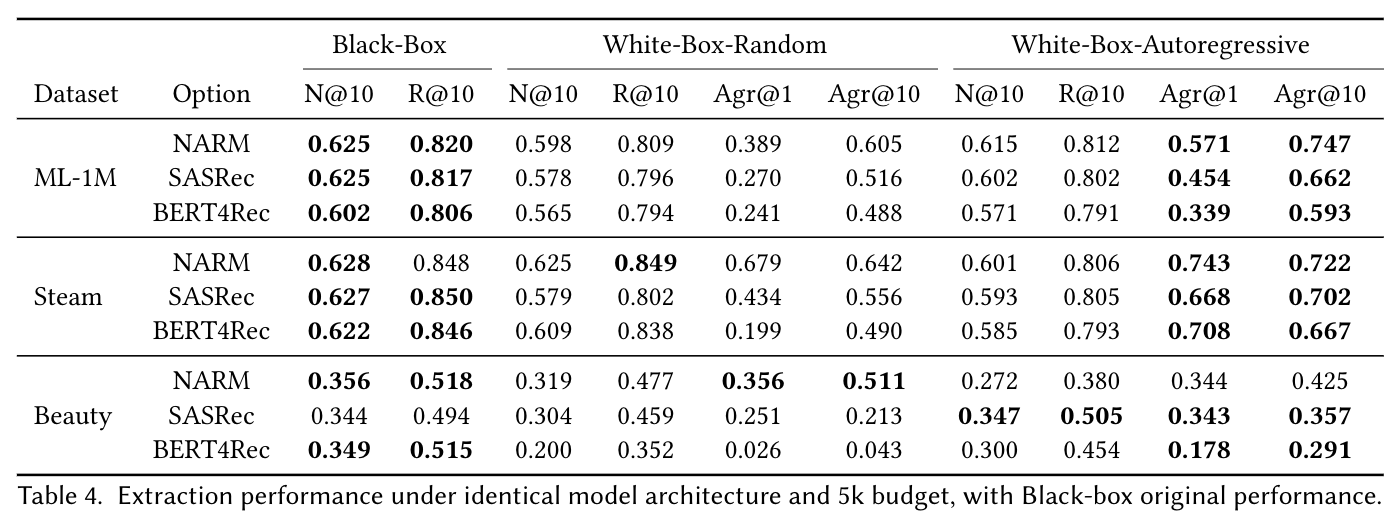

In [ ]:
from IPython.display import Image

Image('/content/drive/MyDrive/CSCI4880 Group Project/Group Project/RecSys/pics/extraction.png')

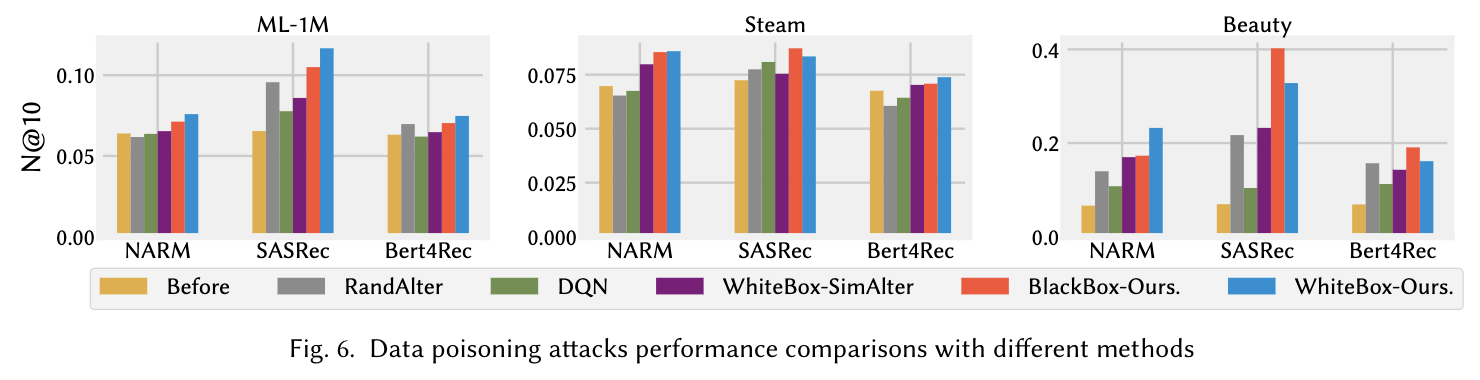

In [ ]:
Image('/content/drive/MyDrive/CSCI4880 Group Project/Group Project/RecSys/pics/poisoning.png')

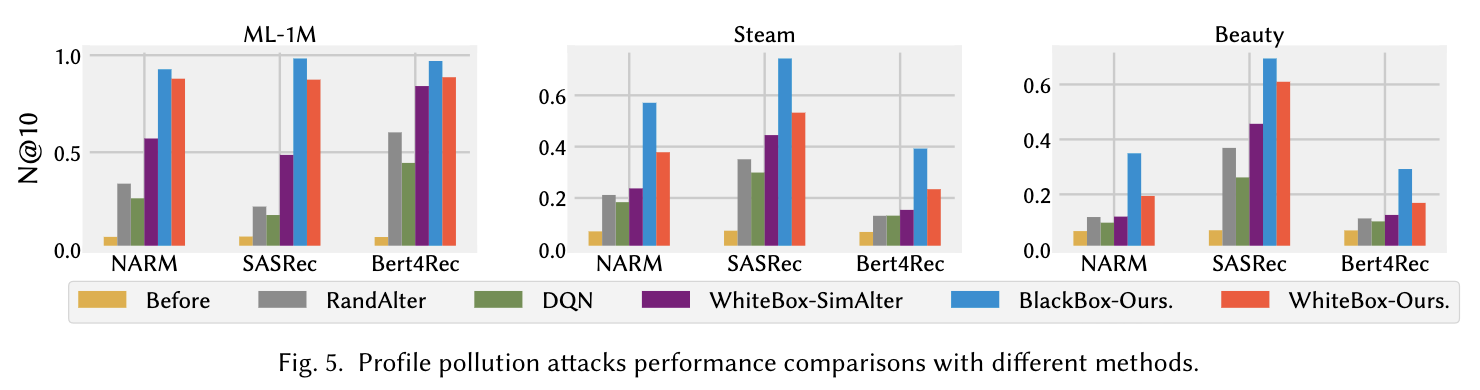

In [ ]:
Image('/content/drive/MyDrive/CSCI4880 Group Project/Group Project/RecSys/pics/pollution.png')

Our results:

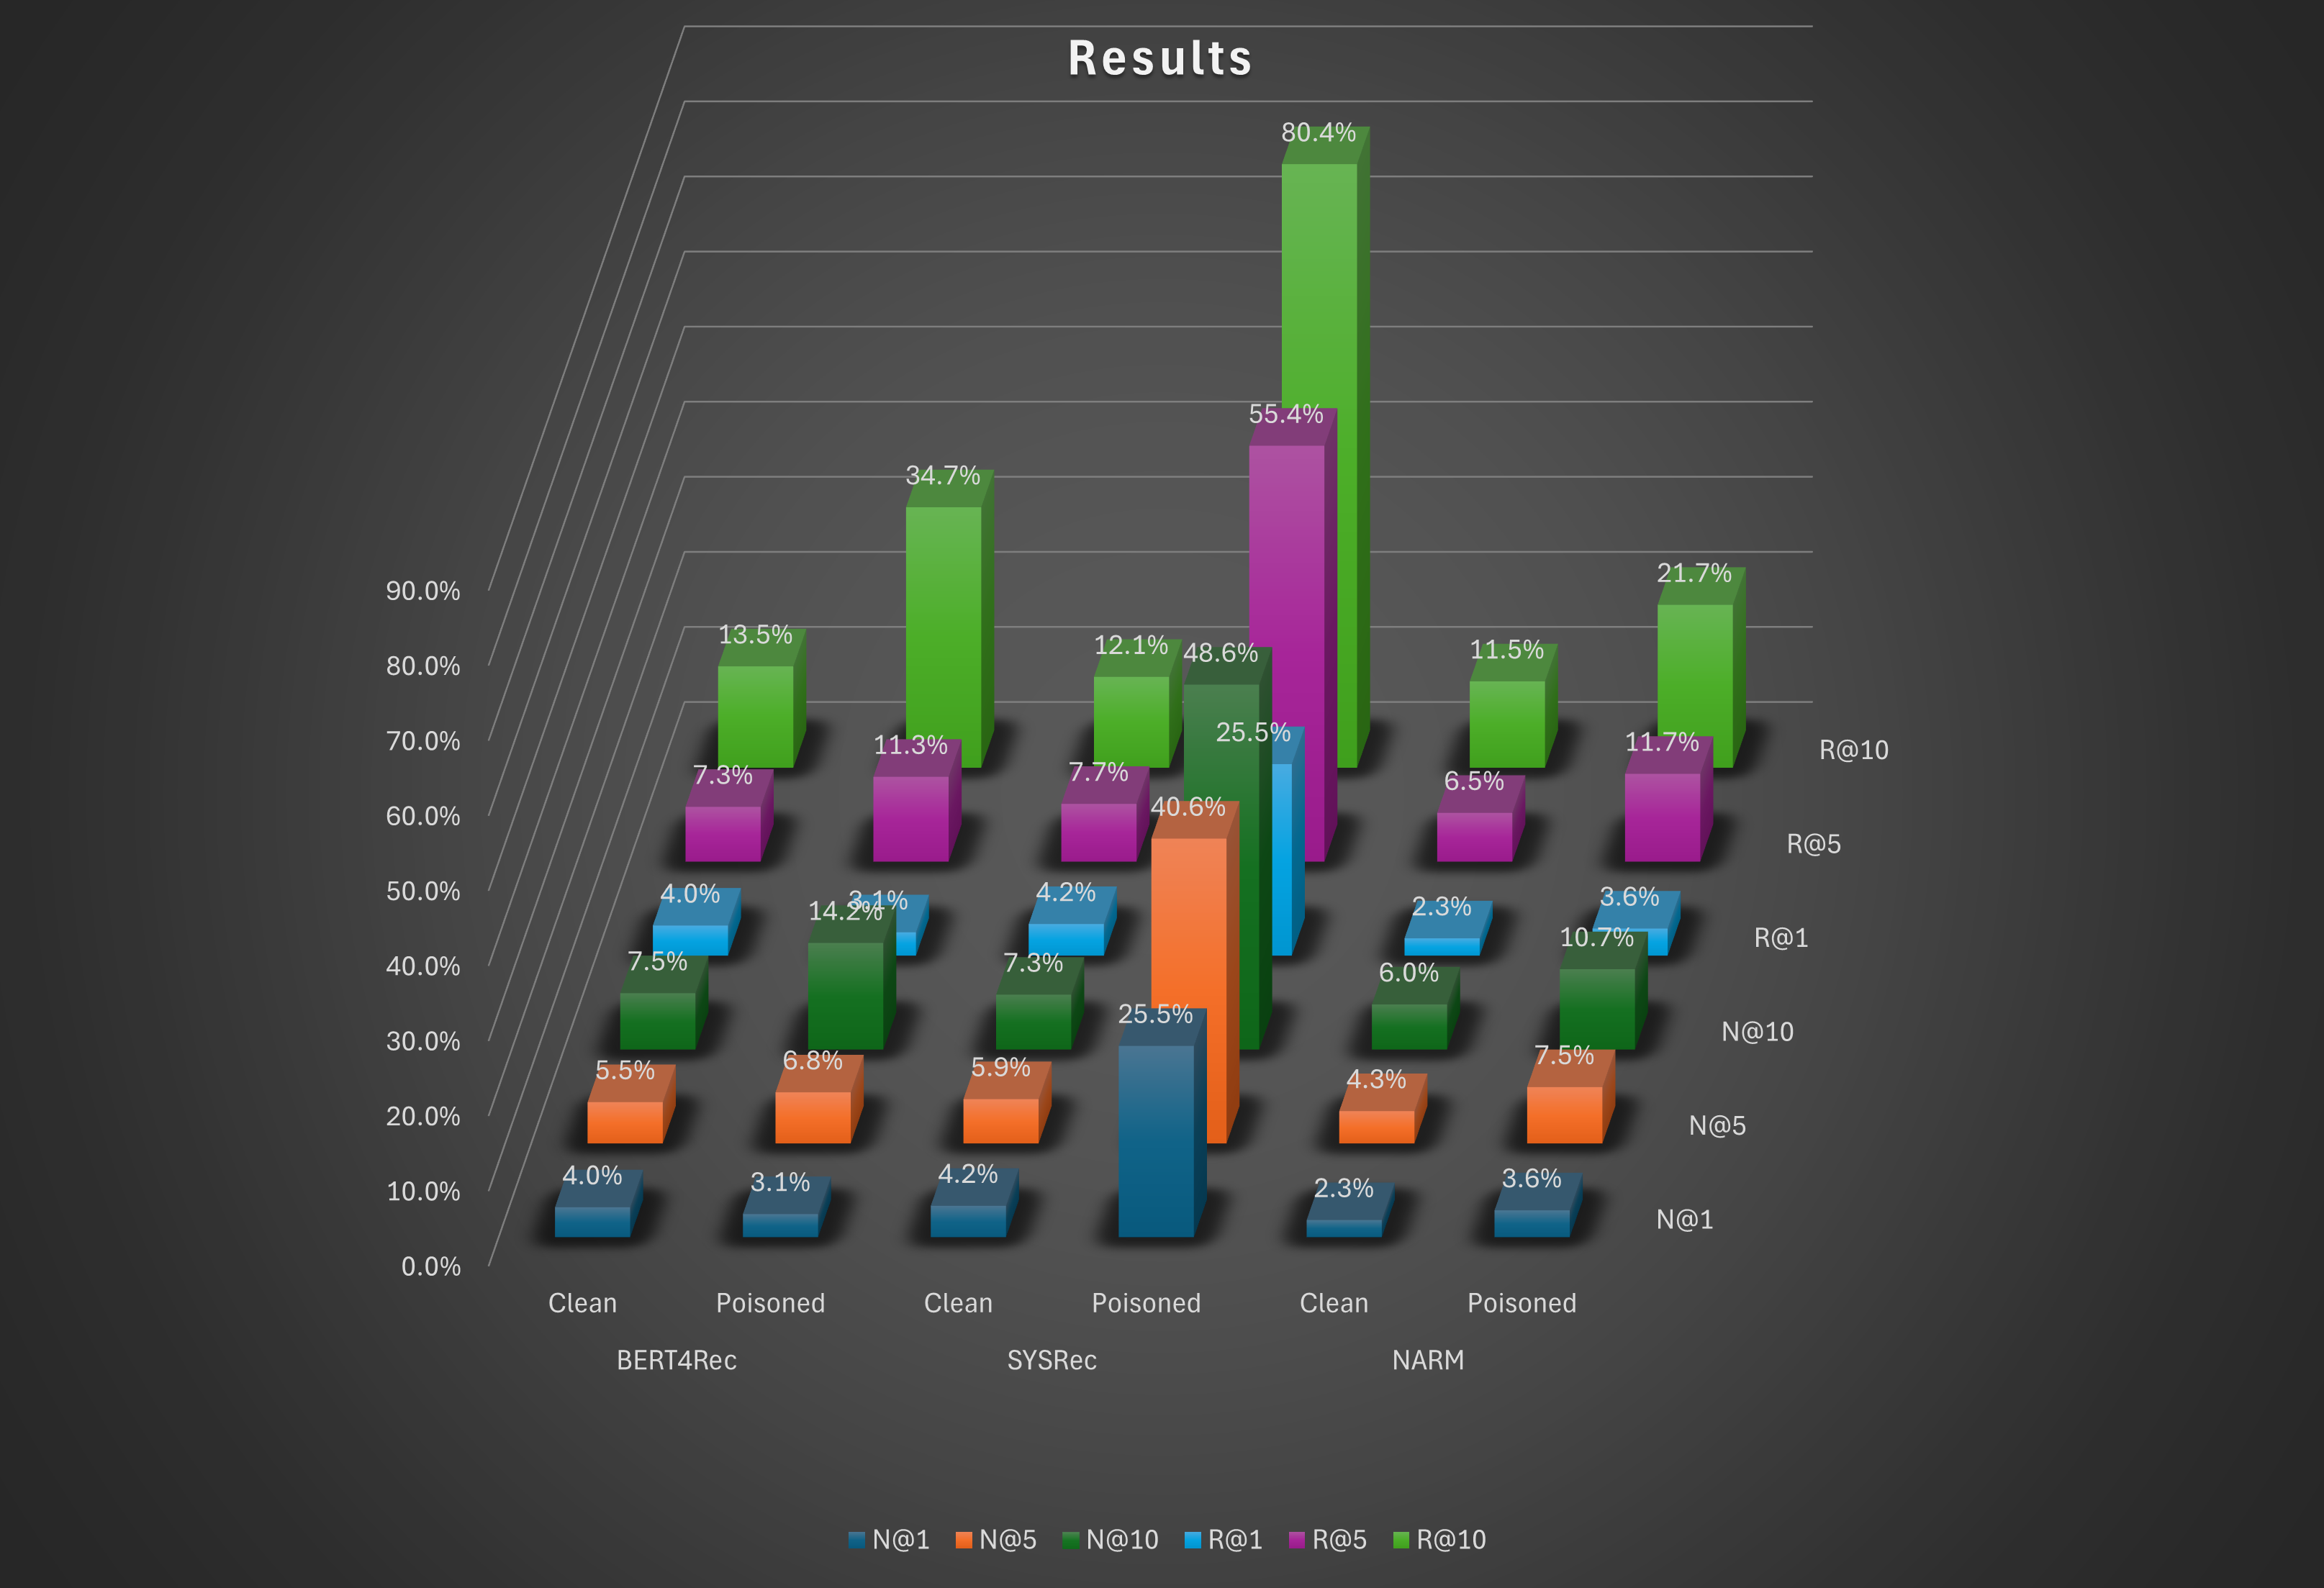

In [ ]:
Image('/content/drive/MyDrive/CSCI4880 Group Project/Group Project/RecSys/pics/results.png')

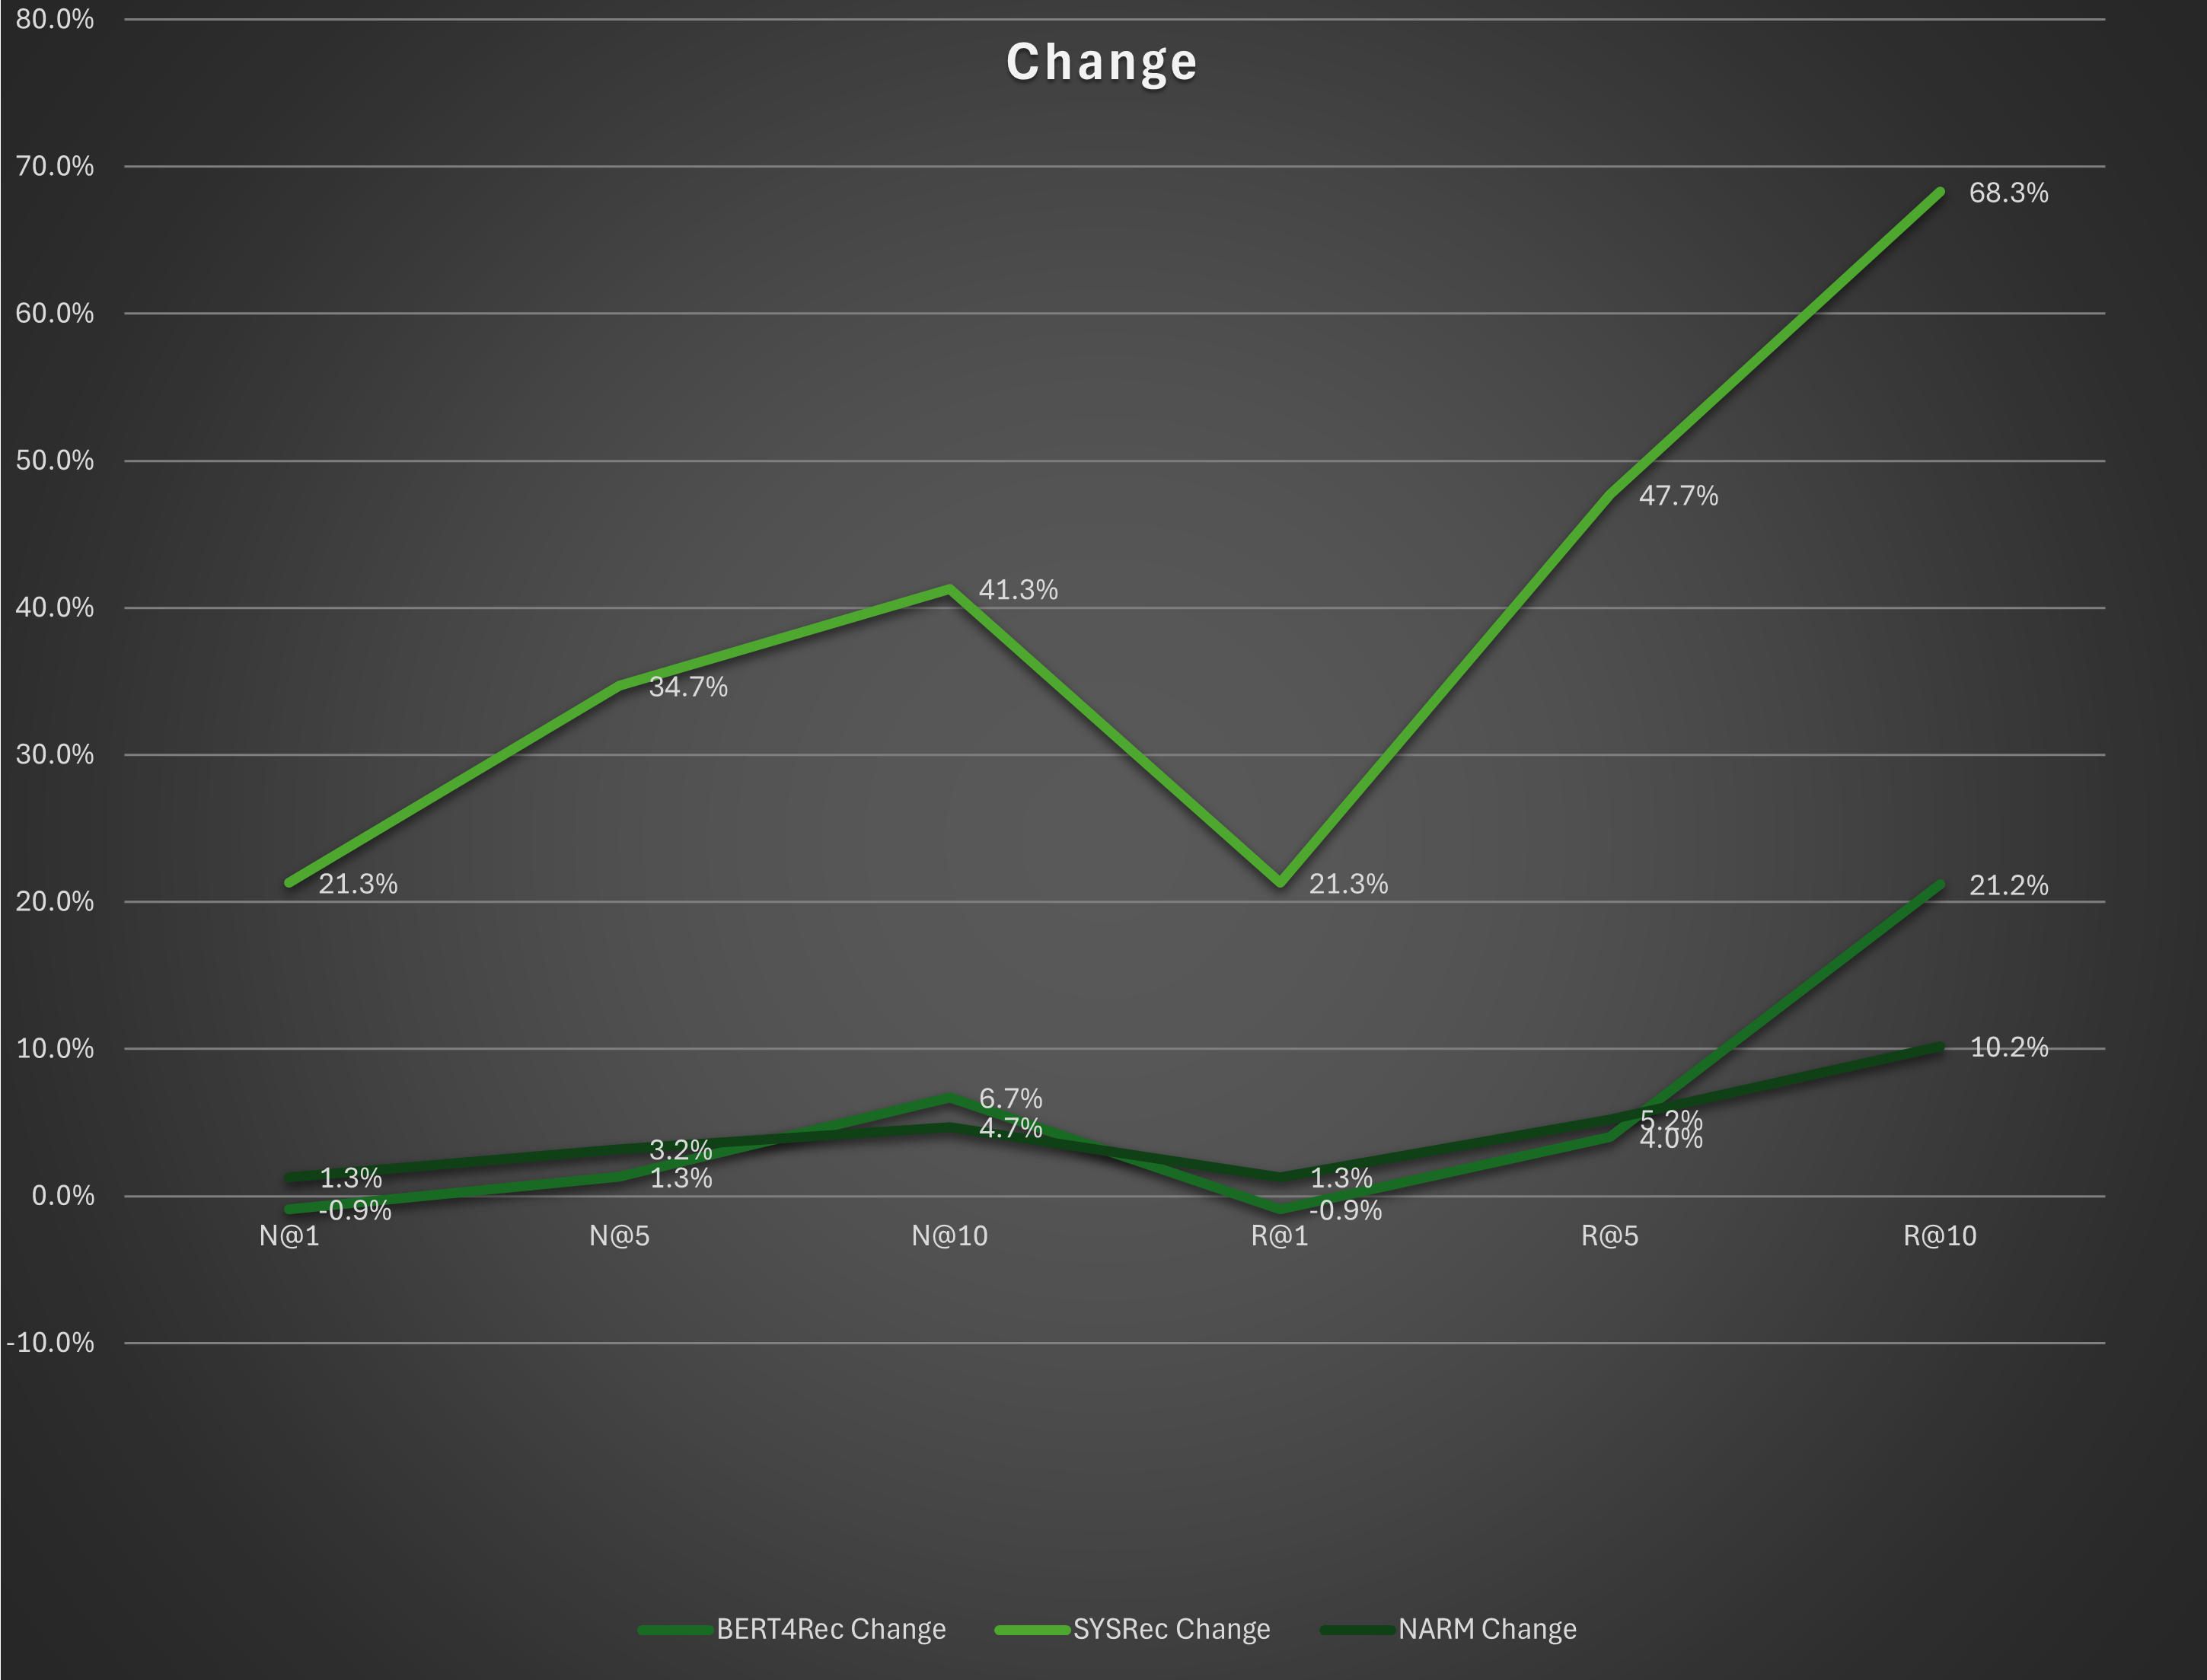

In [ ]:
Image('/content/drive/MyDrive/CSCI4880 Group Project/Group Project/RecSys/pics/change.png')

# III. Push all completed data back to the GitHub Repo
And shut down the runtime (Gotta save those compute credits!)

In [ ]:
with open('/content/drive/MyDrive/token.txt', 'r') as file:
    token = file.read().strip()
!git remote set-url origin https://{token}:@github.com/Huraharah/RecSys-Extraction-Attack.git
!git add .
!git commit -m "Project Complete"
!git push origin main

In [ ]:
from google.colab import runtime
runtime.unassign()